# Bitcoin Digital Twin (Refactored)

This notebook is a thin wrapper around reusable modules in `src/`.
Run top-to-bottom.


In [12]:
# If running from /notebooks in Colab, add repo root to path
import sys
from pathlib import Path
repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from src.data import download_data
from src.features import build_features, make_seqs
from src.models import train_return_model, train_direction_model, train_lstm_classifier
from src.evaluate import regression_metrics, classification_metrics, find_best_threshold
from src.strategy import confidence_weighted_positions, equity_curves_from_positions, compare_returns

plt.style.use('seaborn-v0_8')

# settings
TICKER = 'BTC-USD'
PERIOD = '60d'
INTERVAL = '5m'
LOOKBACK = 60
HORIZON = 3


In [4]:
df_raw = download_data(TICKER, period=PERIOD, interval=INTERVAL)
df_raw.columns = df_raw.columns.get_level_values(0)   # MultiIndex flatten
print('Raw data shape:', df_raw.shape)
df_raw.head()

Raw data shape: (17262, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-08-01 00:00:00+00:00,62891.851562,62891.851562,62905.859375,62824.781250,62832.519531,0
2026-08-01 00:05:00+00:00,62887.218750,62887.218750,62904.960938,62869.390625,62891.500000,0
2026-08-01 00:10:00+00:00,62888.191406,62888.191406,62908.480469,62883.199219,62883.199219,65466368
2026-08-01 00:15:00+00:00,62896.968750,62896.968750,62905.000000,62870.320312,62883.199219,0
2026-08-01 00:20:00+00:00,62905.000000,62905.000000,62905.000000,62886.640625,62898.191406,261720064


In [13]:
x, y_reg, y_class, df_feat = build_features(df_raw, horizon=HORIZON)
df_feat.head()


Price,Adj Close,Close,High,Low,Open,Volume,return_1,future_close,future_return,future_up,...,sma20,ema10,ema20,vol10,vol20,mom5,mom10,rsi14,macd,macd_signal
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-08-01 01:40:00+00:00,62909.511719,62909.511719,62914.371094,62888.968750,62888.968750,0,0.000326,62903.039062,-0.000103,0,...,62898.855859,62891.313000,62894.125660,0.000305,0.000254,0.000084,0.000001,47.548135,-2.597134,-1.220103
2026-08-01 01:45:00+00:00,62903.851562,62903.851562,62914.160156,62903.839844,62909.511719,0,-0.000090,62924.160156,0.000323,1,...,62899.687500,62893.592739,62895.051936,0.000247,0.000255,0.000092,0.000045,44.104762,-1.467561,-1.269595
2026-08-01 01:50:00+00:00,62898.589844,62898.589844,62903.851562,62880.601562,62903.839844,0,-0.000084,62912.691406,0.000224,1,...,62900.207422,62894.501303,62895.388880,0.000239,0.000256,0.000056,0.000011,40.421237,-0.985581,-1.212792
2026-08-01 01:55:00+00:00,62903.039062,62903.039062,62903.039062,62886.480469,62898.589844,0,0.000071,62952.398438,0.000785,1,...,62900.510938,62896.053623,62896.117469,0.000239,0.000254,0.000129,0.000013,41.089080,-0.241807,-1.018595
2026-08-01 02:00:00+00:00,62924.160156,62924.160156,62924.160156,62903.039062,62903.039062,0,0.000336,62978.109375,0.000857,1,...,62901.468945,62901.163902,62898.788201,0.000259,0.000264,0.000112,0.000035,53.950625,2.028551,-0.409166


In [14]:
# Train/test split (chronological)
n = len(df_feat)
train_size = int(n * 0.7)

x_train = x[:train_size]
x_test = x[train_size:]
y_return_train = y_reg[:train_size]
y_return_test = y_reg[train_size:]
y_direction_train = y_class[:train_size]
y_direction_test = y_class[train_size:]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print('Train:', x_train.shape, '| Test:', x_test.shape)


Train: (12067, 13) | Test: (5172, 13)


In [15]:
# Baselines: Linear Regression (return) + Logistic Regression (direction)
return_model = train_return_model(x_train_scaled, y_return_train)
y_return_pred = return_model.predict(x_test_scaled)
print('Linear Regression:', regression_metrics(y_return_test, y_return_pred))

direction_model = train_direction_model(x_train_scaled, y_direction_train)
y_direction_pred = direction_model.predict(x_test_scaled)
print('Logistic Regression:', classification_metrics(y_direction_test, y_direction_pred))


Linear Regression: {'MAE': 0.0012582278714210497, 'RMSE': 0.001913418716250561, 'R2': -0.0003319092699027859}
Logistic Regression: {'Accuracy': 0.5278422273781903, 'Precision': 0.5486005089058524, 'Recall': 0.40941891378655526, 'F1': 0.4688995215311005}


In [18]:
x_all_scaled = scaler.transform(x)
x_seq, y_seq = make_seqs(x_all_scaled, y_class, lookback=LOOKBACK)

n_seq = len(x_seq)
train_end = int(n_seq * 0.6)
val_end = int(n_seq * 0.8)

x_seq_train, y_seq_train = x_seq[:train_end], y_seq[:train_end]
x_seq_val,   y_seq_val   = x_seq[train_end:val_end], y_seq[train_end:val_end]
x_seq_test,  y_seq_test  = x_seq[val_end:], y_seq[val_end:]

print('Train:', x_seq_train.shape, '| Val:', x_seq_val.shape, '| Test:', x_seq_test.shape)

Train: (10307, 60, 13) | Val: (3436, 60, 13) | Test: (3436, 60, 13)


In [20]:
# Train LSTM classifier
model, history, class_weights = train_lstm_classifier(
    x_seq_train, y_seq_train,
    lookback=LOOKBACK,
    n_features=x_seq_train.shape[2],
    epochs=50,
    batch_size=64,
    patience=6,
)
print('Class weights:', class_weights)


c:\Users\Praful Jha\Desktop\siemens\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.5104 - loss: 0.6939 - val_accuracy: 0.5276 - val_loss: 0.6914
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.5289 - loss: 0.6914 - val_accuracy: 0.5325 - val_loss: 0.7001
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.5284 - loss: 0.6907 - val_accuracy: 0.5116 - val_loss: 0.6935
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5294 - loss: 0.6898 - val_accuracy: 0.5078 - val_loss: 0.6999
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.5378 - loss: 0.6881 - val_accuracy: 0.5019 - val_loss: 0.7041
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5470 - loss: 0.6862 - val_accuracy: 0.5112 - val_loss: 0.6972
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5447 - loss: 0.6850 - val_accuracy: 0.5107 - val_loss: 0.6993
Class weights: {0: np.float64(0.9997090203685742), 1: np.float64(1.000291149068323)}


In [21]:
y_prob_val = model.predict(x_seq_val).reshape(-1)
best_t, best_metrics = find_best_threshold(y_seq_val, y_prob_val)
print('Best threshold (val):', best_t)
print('Metrics on val:', best_metrics)

y_prob = model.predict(x_seq_test).reshape(-1)
test_acc = ((y_prob >= best_t).astype(int) == y_seq_test).mean()
print('Test accuracy at that threshold:', round(test_acc, 4))

108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step
Best threshold (val): 0.1
Metrics on val: {'Accuracy': 0.4863213038416764, 'Precision': 0.4863213038416764, 'Recall': 1.0, 'F1': 0.6543959271588017}
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Test accuracy at that threshold: 0.5186


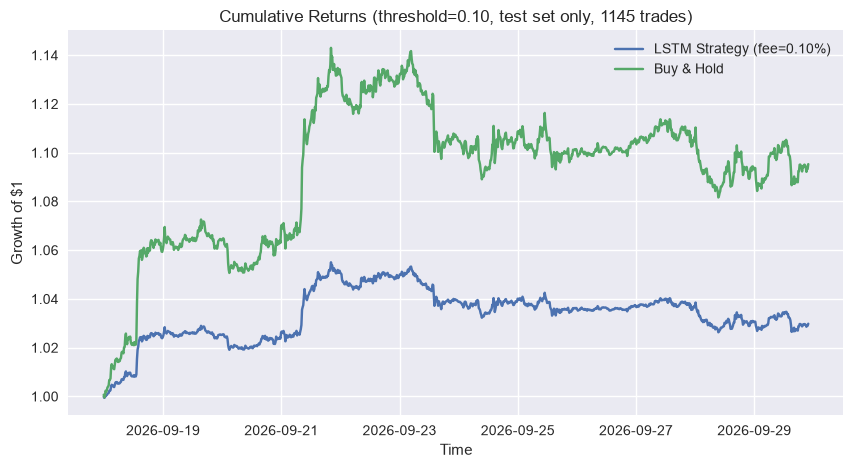

Number of trades: 1145
Avg turnover per trade: 0.012022279157388679
{'strategy_avg': 2.5989028858723467e-05, 'strategy_vol': 0.0008144043496552524, 'baseline_avg': 8.135779334532718e-05, 'baseline_vol': 0.0019320233409172438, 't_stat': -0.8932037800816918, 'p_value': 0.37188778150007057}


In [22]:
FEE = 0.001  # 0.1% per unit of position change (fee + slippage)
H = HORIZON

test_start = LOOKBACK + val_end
prices = df_feat['Close'].iloc[test_start:test_start + len(y_prob)]

positions = np.asarray(confidence_weighted_positions(y_prob, threshold=best_t), dtype=float)

p = prices.values
idx = np.arange(0, len(p) - H, H)          # har H candles par ek trade

trade_pos = positions[idx]
trade_ret = p[idx + H] / p[idx] - 1

turnover = np.abs(np.diff(trade_pos, prepend=0.0))
strategy_ret = pd.Series(trade_pos * trade_ret - FEE * turnover, index=prices.index[idx])
baseline_ret = pd.Series(trade_ret, index=prices.index[idx])

strategy_eq = (1 + strategy_ret).cumprod()
baseline_eq = (1 + baseline_ret).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(strategy_eq, label=f'LSTM Strategy (fee={FEE:.2%})')
plt.plot(baseline_eq, label='Buy & Hold')
plt.title(f'Cumulative Returns (threshold={best_t:.2f}, test set only, {len(idx)} trades)')
plt.ylabel('Growth of $1')
plt.xlabel('Time')
plt.grid(True)
plt.legend()
plt.show()

print('Number of trades:', len(idx))
print('Avg turnover per trade:', turnover.mean())
print(compare_returns(strategy_ret, baseline_ret))